In [10]:
!pip -q install ultralytics seaborn

import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO
from google.colab.patches import cv2_imshow

In [11]:
# Imagen (ya subida a Colab)
IMAGE_PATH = "/content/yolo_imagen_experimentacion_parametros.jpg"

# Modelo YOLO
MODEL_NAME = "yolov8n.pt"

# IoU fijo para TODAS las configuraciones
IOU_FIXED = 0.50

# Configuraciones de conf
CONFIGS = {
    "Conservadora": 0.50,
    "Balanceada":   0.25,
    "Agresiva":     0.15
}

In [12]:
model = YOLO(MODEL_NAME)

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen en: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [13]:
def run_experiment(config_name, conf_value, iou_value=0.50):
    t0 = time.perf_counter()

    result = model.predict(
        source=img_bgr,
        conf=conf_value,
        iou=iou_value,
        verbose=False
    )[0]

    t1 = time.perf_counter()

    if result.boxes is not None and len(result.boxes) > 0:
        confs = result.boxes.conf.cpu().numpy().tolist()
    else:
        confs = []

    output = {
        "Configuración": config_name,
        "Conf": conf_value,
        "IoU": iou_value,
        "Objetos detectados": len(confs),
        "Confianza promedio": float(np.mean(confs)) if confs else 0.0,
        "Tiempo de ejecución (s)": t1 - t0,
        "confs_individuales": confs,
        "img_anotada_rgb": cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB),
    }

    return output

In [14]:
results = []
for name, conf in CONFIGS.items():
    results.append(run_experiment(name, conf, IOU_FIXED))

df = pd.DataFrame([{
    "Configuración": r["Configuración"],
    "Conf": r["Conf"],
    "IoU": r["IoU"],
    "Objetos detectados": r["Objetos detectados"],
    "Confianza promedio": round(r["Confianza promedio"], 4),
    "Tiempo de ejecución (s)": round(r["Tiempo de ejecución (s)"], 4),
} for r in results])

display(df)

,Configuración,Conf,IoU,Objetos detectados,Confianza promedio,Tiempo de ejecución (s)
0,Conservadora,0.50,0.5,10,0.6867,0.0648
1,Balanceada,0.25,0.5,23,0.5046,0.0093
2,Agresiva,0.15,0.5,38,0.3808,0.0142


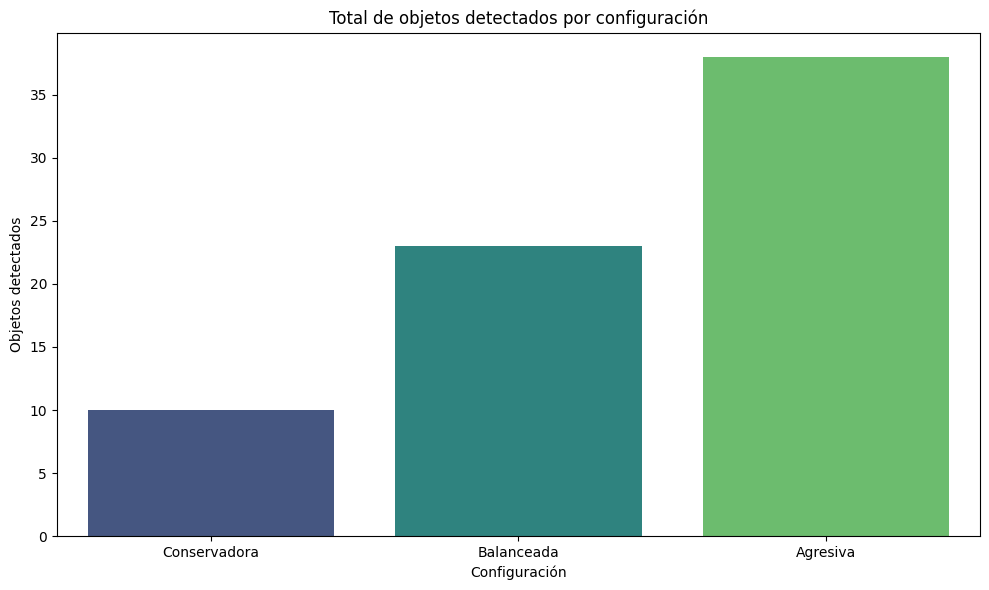

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Configuración", y="Objetos detectados", hue="Configuración", palette="viridis", legend=False)
plt.title("Total de objetos detectados por configuración")
plt.xlabel("Configuración")
plt.ylabel("Objetos detectados")
plt.tight_layout()
plt.show()

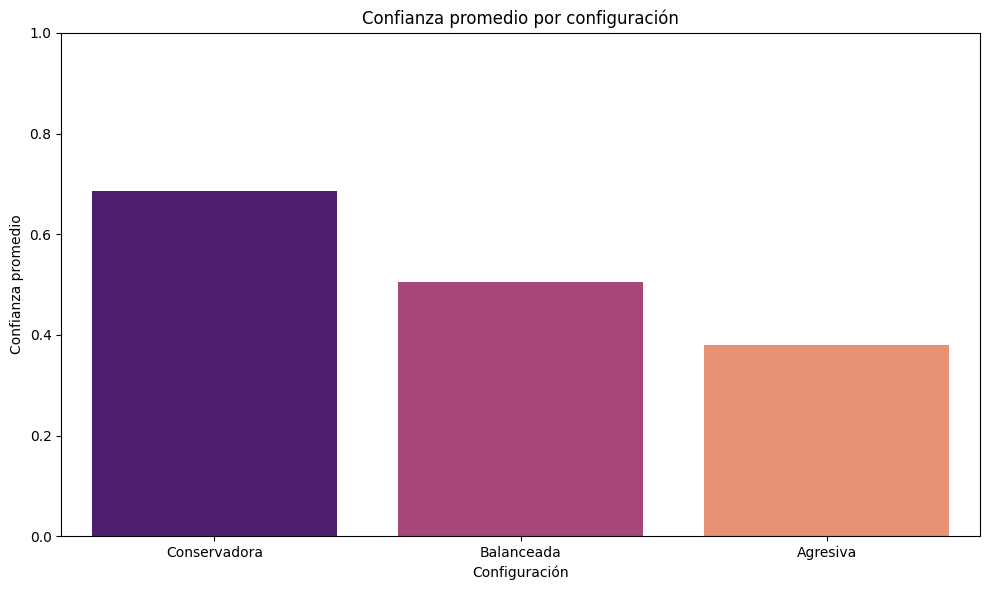

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Configuración", y="Confianza promedio", hue="Configuración", palette="magma", legend=False)
plt.title("Confianza promedio por configuración")
plt.xlabel("Configuración")
plt.ylabel("Confianza promedio")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

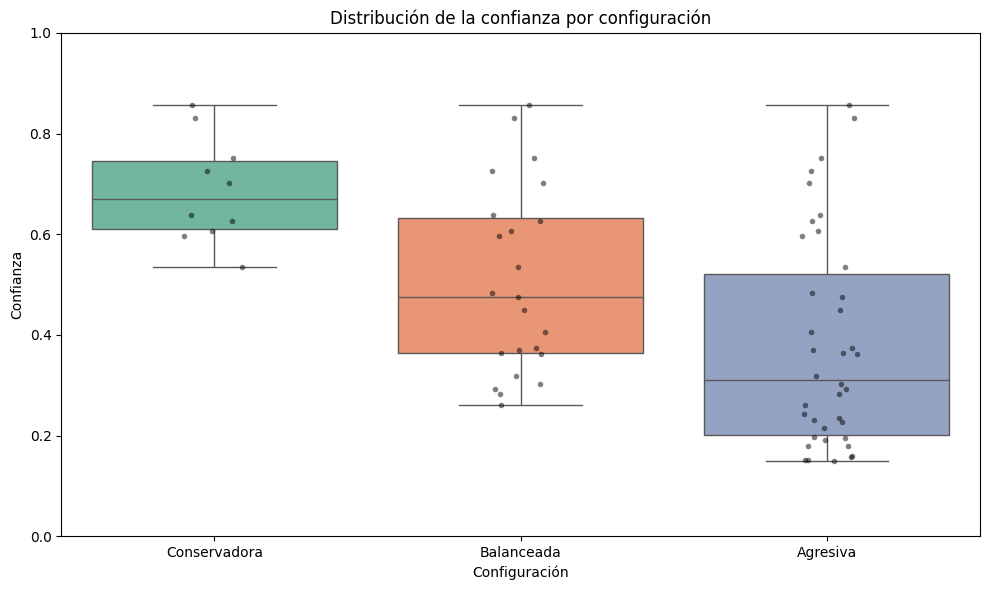

In [17]:
rows = []
for r in results:
    for c in r["confs_individuales"]:
        rows.append({"Configuración": r["Configuración"], "Confianza": c})

df_conf = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))
if not df_conf.empty:
    sns.boxplot(data=df_conf, x="Configuración", y="Confianza", hue="Configuración", palette="Set2", legend=False)
    sns.stripplot(data=df_conf, x="Configuración", y="Confianza", color="black", alpha=0.5, size=4)
else:
    plt.text(0.5, 0.5, "No hubo detecciones para graficar", ha="center", va="center")

plt.title("Distribución de la confianza por configuración")
plt.xlabel("Configuración")
plt.ylabel("Confianza")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Visualización de las detecciones por configuración:
### Imagen Original


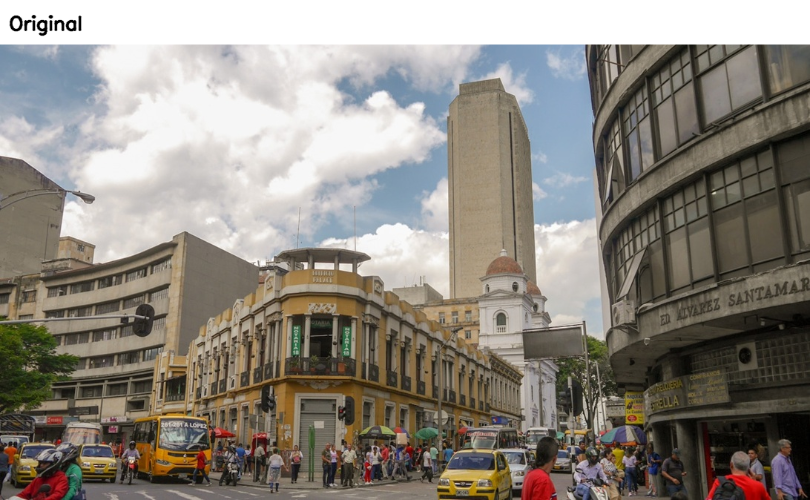



### Configuración: Conservadora


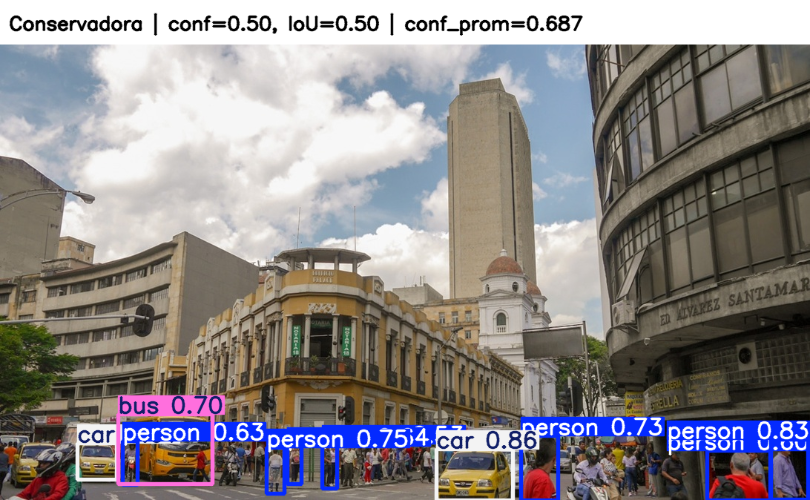



### Configuración: Balanceada


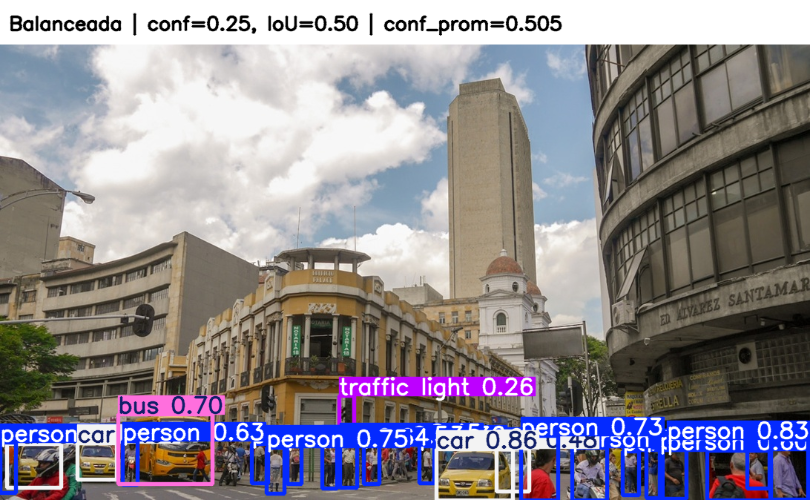



### Configuración: Agresiva


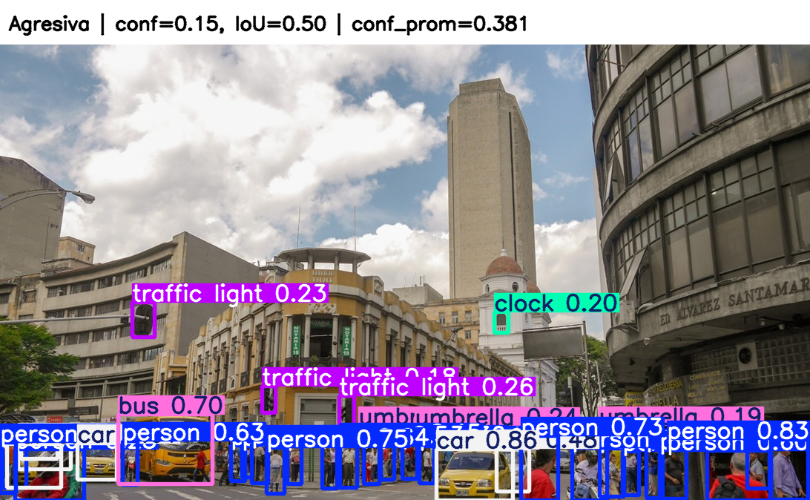

In [18]:
def add_header(img_rgb, text):
    h, w = img_rgb.shape[:2]
    header = np.ones((60, w, 3), dtype=np.uint8) * 255
    cv2.putText(header, text, (12, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0, 0, 0), 2, cv2.LINE_AA)
    return np.vstack([header, img_rgb])

def resize_to_height(imgs, target_h=500):
    out = []
    for im in imgs:
        h, w = im.shape[:2]
        new_w = int(w * (target_h / h))
        out.append(cv2.resize(im, (new_w, target_h)))
    return out

# Prepare original image with header
panel_original = add_header(img_rgb, "Original")
panels_to_display = [panel_original]

# Prepare annotated images with headers
for r in results:
    txt = f'{r["Configuración"]} | conf={r["Conf"]:.2f}, IoU={r["IoU"]:.2f} | conf_prom={r["Confianza promedio"]:.3f}'
    panels_to_display.append(add_header(r["img_anotada_rgb"], txt))

# Resize all panels to a common height
panels_to_display = resize_to_height(panels_to_display, target_h=500)

print("Visualización de las detecciones por configuración:")

for i, panel in enumerate(panels_to_display):
    # Convert panel from RGB to BGR for cv2_imshow
    panel_bgr = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
    if i == 0:
        print("### Imagen Original")
    else:
        # Get configuration name from results for better description
        config_name = results[i-1]["Configuración"]
        print(f"### Configuración: {config_name}")
    cv2_imshow(panel_bgr)
    print("\n") # Add a newline for better visual separation